# <span style="color: #d9534f;"> Setup and Import </span>

In [101]:
# Import libraries.
import os

import pandas as pd

print(f"Pandas version: {pd.__version__}")

import numpy as np
print(f"Numpy version: {np.__version__}")

import openpyxl
print(f"Openpyxl version: {openpyxl.__version__}")

# When importing a sub-module so we don't do version checking on it directly.
import matplotlib.pyplot as plt

# For more plot options.
import seaborn as sns

# For data validation.
import pandera.pandas as pa

# For statistical tests.
from scipy import stats

Pandas version: 2.3.3
Numpy version: 2.2.6
Openpyxl version: 3.1.5


\newpage

In [2]:
'''
We will want to import the schema used for 'PUFYEAR','OPTIME',
 'AGE', and 'SEX', as well as the 'check_data' function we used
 to get a printout of how many rows have column values that don't
 match the schema.
'''
from utilities import base_schema, check_data

In [3]:
# Set some options for pandas so that it doesn't truncate the dataframe
#   view window.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [4]:
# Import the raw data.
file_path = os.path.join('..', 'Data', 'Updated_NSQIP_83083.xlsx')
raw_df = pd.read_excel(file_path)

\newpage

# <span style="color: #d9534f;"> Data Cleaning </span>

We will want to add a comorbidities count column as described in the module intro (Gatekeeper Tests).

We want to turn 'SEPSIS' into a binary variable and add a 'Comorbidities Count' column that caps at 3+.

Similar to the previous assignment, I'll use Pandera to check for any 'strange' values for these columns.

After that, we'll create the variables.

In [5]:
# Create a copy of the raw data.
df = raw_df.copy()

In [6]:
comorbidity_schema = pa.DataFrameSchema({
    # Comorbidity Columns are binary and should be 0 or 1.
    # The ** allows us to unpack the dictionary into the schema.
    # i.e., the same values make sense for all of the columns.
    **{col: pa.Column(
        int,
        checks=pa.Check.isin([0, 1]),
        nullable=False,
        coerce=True
    ) for col in [
        'DIABETES', 'SMOKE', 'DYSPNEA', 'VENTILAT', 'HXCOPD', 'ASCITES',
        'HXCHF', 'HYPERMED', 'RENAFAIL', 'DIALYSIS', 'DISCANCR', 'WNDINF',
        'STEROID', 'WTLOSS', 'BLEEDIS', 'TRANSFUS'
    ]},
    # PRSEPIS should be one of the expected categorical values
    "PRSEPIS": pa.Column(
        str,
        checks=pa.Check.isin(["None", "Sepsis", "Septic Shock", "SIRS"]),
        nullable=False
    ),
    # BMI should be in a reasonable range
    "BMI": pa.Column(
        float,
        checks=pa.Check.in_range(10, 150),
        coerce=True
    ),
})

In [7]:
# This keeps the 'count' values from splitting off from the rest of the
#   returned dataframe.
pd.set_option('display.colheader_justify', 'left')
pd.set_option('display.expand_frame_repr', False)

# Let's see what we get.
check_data(df, comorbidity_schema)

Summary of Validation Errors:


,column,check,failure_case,count
11,PRSEPIS,not_nullable,NaN,82730
0,BLEEDIS,coerce_dtype('int64'),NaN,39190
2,BLEEDIS,not_nullable,NaN,39190
8,DIABETES,"isin([0, 1])",2,1920
9,DYSPNEA,"isin([0, 1])",2,1706
7,BMI,not_nullable,NaN,848
10,PRSEPIS,"isin(['None', 'Sepsis', 'Septic Shock', 'SIRS'])",Septic,11
1,BLEEDIS,dtype('int64'),float64,1
3,BMI,"in_range(10, 150)",9.546682,1
4,BMI,"in_range(10, 150)",9.632569,1


Almost all of the 'PRSEPIS' values are 'NAN'.

\newpage

## PRSEPSIS Recoding

In [8]:
df["PRSEPIS"].unique()

array([nan, 'Septic Shock', 'SIRS', 'Sepsis', 'Septic'], dtype=object)

As the module lays out, I'm going to count 'NaN' ('None') values here as 0 and other values as '1.'

If we wanted to keep the categorical values, I'd probably just opt to re-code 'Septic' as 'Sepsis.'

We'll check this again below with a schema for our derived column(s).

So there's not really an issue with these values.

In [9]:
# Create a binary variable for SEPSIS: 0 for "None" and 1 for any other values.
df.loc[:, 'SEPSIS'] = df['PRSEPIS'].notna().astype(int)

In [10]:
# We should see only two values now.
df["SEPSIS"].value_counts()

SEPSIS
0    82730
1      353
Name: count, dtype: int64

\newpage

## BLEEDIS Recoding

The other big one here is the 'BLEEDIS' values.

In [11]:
df["BLEEDIS"].unique()

array([nan,  0.,  1.])

The data dictionary (NSQIP_PUF_User_Guide_2015) specifies that this should be a value of '0' or '1' (see page 14, row 35).

I'm going to replace the NaN values with '0' per the Exercise 2 instructions.

In [12]:
# Drop BLEEDIS = NaN rows.
df.loc[:, 'BLEEDIS'] = df['BLEEDIS'].fillna(0).astype(int)

## Other Comorbities

The Diabetes and Dyspnea columns have '2' values rather than just '0' and '1'.

In the data dictionary, page 13, column 20 says 'DIABETES' can have three values: 'INSULIN,' 'NO,' and 'NON-INSULIN.'

Same page (p.13), column 22 says 'DYSPNEA' can have three values: 'AT REST,' 'MODERATE EXERTION,' and 'NO.'

So, we can ignore the thrown errors for these since the '2' values will apply to one of those categories.

For the BMI column, there are some NaN values but there's relatively few for the size of the dataset.

I'll opt to drop these. The other values are close to 10 so I'm guessing they're just outliers.

In [13]:
# Drop BMI = NaN rows.
df = df.dropna(subset=['BMI'])

\newpage

## Comorbitities Count Column Creation

In [14]:
# Define the 17 comorbidity columns
comorbidity_columns = [
    'DIABETES', 'SMOKE', 'DYSPNEA', 'VENTILAT', 'HXCOPD', 'ASCITES',
    'HXCHF', 'HYPERMED', 'RENAFAIL', 'DIALYSIS', 'DISCANCR', 'WNDINF',
    'STEROID', 'WTLOSS', 'BLEEDIS', 'TRANSFUS', 'SEPSIS'
]

In [15]:
# Create COMORBIDITIES with binning (cap at 3)
df.loc[:, 'COMORBIDITIES'] = df[comorbidity_columns].sum(axis=1).clip(upper=3)

In [16]:
# Validate the column values.
derived_schema = pa.DataFrameSchema({
    "SEPSIS": pa.Column(int, checks=pa.Check.isin([0, 1]), nullable=False),
    "COMORBIDITIES": pa.Column(int, checks=pa.Check.isin([0, 1, 2, 3]),
                               nullable=False),
})

In [17]:
check_data(df, derived_schema)

Summary of Validation Errors:


,column,check,failure_case,count
0,COMORBIDITIES,dtype('int64'),float64,1


It looks like we ended up with one of the values typed as a float instead of an int, so I'm just going to re-run this and specify the type casting.

In [39]:
# Looking ahead, I'm going to make one column for the actual counts
#   and one for the categorical mapping.
df.loc[:, 'COMORBIDITIES COUNT'] = (
    df[comorbidity_columns].sum(axis=1)
    #.clip(upper=3)
    .astype(int)
    #.map({0: '0', 1: '1', 2: '2', 3: '3+'})
    #.astype('category')
)

# First convert to numeric (float) values, where the upper cap at 3 is for 3+.
# We can convert to categorical with a map.
df.loc[:, 'COMORBIDITIES CAT'] = (
    df[comorbidity_columns].sum(axis=1)
    .clip(upper=3)
    .astype(int)
    .map({0: '0', 1: '1', 2: '2', 3: '3+'})
    .astype('category')
)

In [33]:
df["COMORBIDITIES COUNT"].value_counts()

COMORBIDITIES COUNT
0    46183
1    25211
2     6938
3     2608
4      871
5      288
6      100
7       26
8        8
9        2
Name: count, dtype: int64

In [41]:
df["COMORBIDITIES CAT"].value_counts()

COMORBIDITIES CAT
0     46183
1     25211
2      6938
3+     3903
Name: count, dtype: int64

\newpage

## Other Columns

We've already covered these in a previous assignment, so I'm just going to repeat the steps here.

In [21]:
check_data(df,base_schema)

Summary of Validation Errors:


,column,check,failure_case,count
2,OPTIME,greater_than(0),0.0,93
0,AGE,not_nullable,NaN,60
1,OPTIME,greater_than(0),-99.0,10


After removing some of our NaN value rows above, we end up with only 60 additional rows to drop for 'AGE.'

There are also a few here with 'OPTIME' values at 0 or -99 we can drop.

As in the previous assignment, we'll do this using the '.query' function to create our sub-frame. I'll also drop all the non-relevant columns at this step.

In [64]:
# Keeping 'TOTHLOS' here as well, per the Exercise steps.
# This is 'total length of stay' in days.', so we expect most to be zero.
keep_columns = ['PUFYEAR', 'AGE', 'SEX', 'BMI', 'OPTIME',
                'COMORBIDITIES COUNT', 'COMORBIDITIES CAT', 'TOTHLOS']

df_clean = df.query(
    "OPTIME != 0 and OPTIME != -99 "
    "and AGE == AGE"
)[keep_columns].copy()

In [65]:
#| output: false
# I noticed later that some of the 'TOTHLOS' values are -99.
# They're handled later, but I missed it here.
# I'll hide the output from this cell due to the length.
df_clean['TOTHLOS'].value_counts()

TOTHLOS
 0      78369
 1       2097
 2        529
 3        301
 4        163
 5         89
 6         86
 7         56
 10        39
 8         32
-99        30
 9         30
 31        28
 11        26
 14        17
 30        14
 12        13
 13        12
 15        11
 19        11
 32         6
 29         6
 16         6
 20         6
 17         5
 18         5
 23         5
 61         4
 24         4
 92         4
 91         4
 28         4
 22         4
 89         3
 35         3
 63         3
 38         3
 36         3
 21         3
 26         3
 65         2
 34         2
 41         2
 50         2
 27         2
 43         2
 365        2
 104        1
 114        1
 33         1
 70         1
 90         1
 100        1
 53         1
 66         1
 54         1
 44         1
 25         1
 40         1
 67         1
 99         1
 88         1
 48         1
 71         1
 39         1
 77         1
 60         1
 68         1
Name: count, dtype: int64

\newpage

## Final Result

In [66]:
df_clean.shape

(82072, 8)

So we are left with 82,072 rows and 8 columns.

In [67]:
#| output: false
# Output hidden due to dataframe width.
display(df_clean.head(3))

,PUFYEAR,AGE,SEX,BMI,OPTIME,COMORBIDITIES COUNT,COMORBIDITIES CAT,TOTHLOS
0,2014,25.0,male,26.548571,120,1,1,0
1,2014,31.0,male,24.528571,95,0,0,0
2,2014,27.0,male,30.153739,66,0,0,0


\newpage

# <span style="color: #d9534f;"> Analysis </span>

## Preliminaries

I'm going to start by cross-checking the results I get here with what is in '1.0 – Comparing Two Groups: Gatekeeper Tests – Part I.'

In [68]:
df_clean.groupby('SEX')[['AGE', 'BMI', 'COMORBIDITIES COUNT']].agg(
    ['mean', 'std']
)

AGE                   BMI                  COMORBIDITIES COUNT          
       mean       std        mean       std       mean                std      
SEX                                                                            
female  49.954375  15.082200  31.539793  7.992096  0.685754            0.958780
male    45.221298  15.481818  30.540200  6.260534  0.603039            0.881166

For help with the graphs I tried asking Claude, since I have found it more helpful lately:

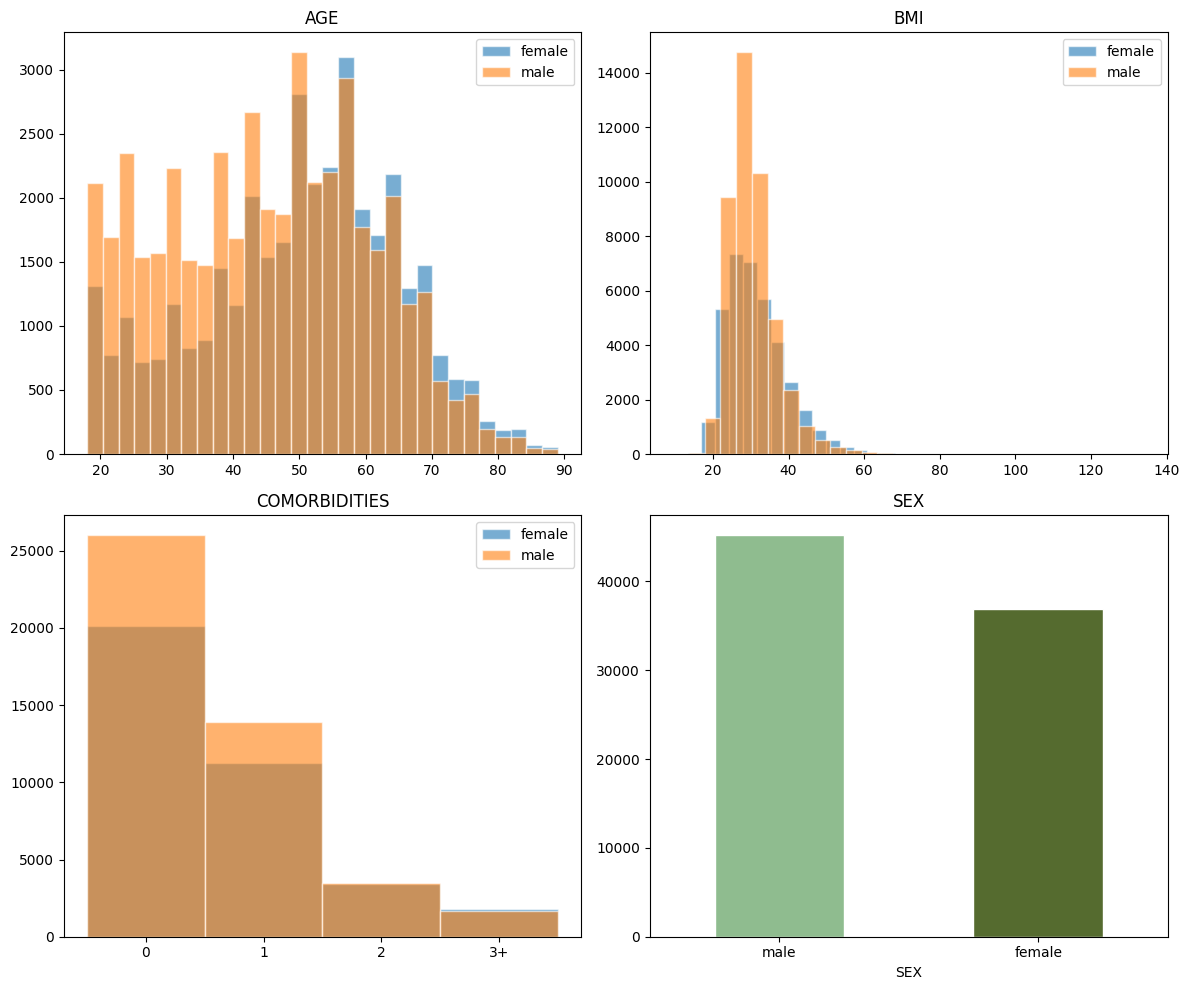

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# AGE
for sex in ['female', 'male']:
    subset = df_clean[df_clean['SEX'] == sex]['AGE']
    axes[0, 0].hist(subset, bins=30, alpha=0.6, label=sex, edgecolor='white')
axes[0, 0].set_title('AGE')
axes[0, 0].legend()

# BMI
for sex in ['female', 'male']:
    subset = df_clean[df_clean['SEX'] == sex]['BMI']
    axes[0, 1].hist(subset, bins=30, alpha=0.6, label=sex, edgecolor='white')
axes[0, 1].set_title('BMI')
axes[0, 1].legend()

# COMORBIDITIES
for sex in ['female', 'male']:
    subset = df_clean[df_clean['SEX'] == sex]['COMORBIDITIES COUNT']
    axes[1, 0].hist(subset, bins=[0, 1, 2, 3, 4], align='left', alpha=0.6,
                     label=sex, edgecolor='white')
axes[1, 0].set_xticks([0, 1, 2, 3])
axes[1, 0].set_xticklabels(['0', '1', '2', '3+'])
axes[1, 0].set_title('COMORBIDITIES')
axes[1, 0].legend()

# SEX counts
df_clean['SEX'].value_counts().plot(kind='bar', ax=axes[1, 1],
                                      color=['#8FBC8F', '#556B2F'],
                                      edgecolor='white')
axes[1, 1].set_title('SEX')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The results are generally similar, except for the Comorbidities means which are slightly different but it still seems similar enough to proceed.

### Two-sample $t$-test (OPTIME by SEX)

#### OPTIME Values

In [48]:
female_optime = df_clean[df_clean['SEX'] == 'female']['OPTIME']
male_optime = df_clean[df_clean['SEX'] == 'male']['OPTIME']

#### Pooled Test

In [179]:
# Pooled (equal variance) t-test. (Similar SD's)
t_stat, p_value = stats.ttest_ind(male_optime, female_optime, equal_var=True)

In [180]:
#| echo: false
print(f"=== Two-Sample t-Test (Pooled) ===")
print(f"  Male mean:   {male_optime.mean():.2f} min (n={len(male_optime)})")
print(
    f"  Female mean: {female_optime.mean():.2f} min (n={len(female_optime)})"
)
print(f"  Difference:  {male_optime.mean() - female_optime.mean():.2f} min")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_value:.6f}")

=== Two-Sample t-Test (Pooled) ===
  Male mean:   49.49 min (n=45206)
  Female mean: 40.58 min (n=36866)
  Difference:  8.91 min
  t-statistic: 29.5903
  p-value:     0.000000


\newpage

#### Cohen's $d$

In [167]:
# We'll create a function to calculate Cohen's d (pooled)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(
        (
            (n1 - 1) * group1.std()**2 + (n2 - 1) * group2.std()**2
        ) / (n1 + n2 - 2)
                         )
    return (group1.mean() - group2.mean()) / pooled_std

In [177]:
# Let's get the calculated value.
d = cohens_d(male_optime, female_optime)

In [178]:
#| echo: false
print(f"=== Effect Size ===")
print(f"  Cohen's d:   {d:.3f}")

=== Effect Size ===
  Cohen's d:   0.208


#### Welch Test

In [175]:
# Welch's Test (Usually for unequal SD's - we'll do this for comparison.)
t_stat_welch, p_value_welch = stats.ttest_ind(
    male_optime, female_optime, equal_var=False
)

In [176]:
#| echo: false
print(f"=== Welch's t-Test ===")
print(f"  t-statistic: {t_stat_welch:.4f}")
print(f"  p-value:     {p_value_welch:.6f}")

=== Welch's t-Test ===
  t-statistic: 30.1556
  p-value:     0.000000


\newpage

#### Wilcoxon Rank-Sum

In [173]:
# 3. Wilcoxon rank-sum (nonparametric alternative)
wilcoxon_stat, wilcoxon_p = stats.mannwhitneyu(
    male_optime, female_optime, alternative='two-sided'
)

In [174]:
#| echo: false
print(f"=== Wilcoxon Rank-Sum ===")
print(f"  U-statistic: {wilcoxon_stat:.0f}")
print(f"  p-value:     {wilcoxon_p:.6f}")

=== Wilcoxon Rank-Sum ===
  U-statistic: 931703958
  p-value:     0.000000


\newpage

# Exercise 2 - Preliminary Work

## Setup

Expected OPTIME from the full clean dataset, by comorbidity group.

In [168]:
# Get the expected OPTIME by counts.
expected_optime = df_clean.groupby(
    'COMORBIDITIES CAT', observed=True
)['OPTIME'].mean()

# We use the 'broadcast' method like in the previous assignment.
# We use the astype(float) to make sure it's numeric,
#   since it's derived from a categorical.
df_clean['Expected_OPTIME'] = df_clean['COMORBIDITIES CAT'].map(
    expected_optime).astype(float)

In [169]:
#| output: false
# Output hidden due to dataframe width.
df_clean.head(3)

,PUFYEAR,AGE,SEX,BMI,OPTIME,COMORBIDITIES COUNT,COMORBIDITIES CAT,TOTHLOS,Expected_OPTIME
0,2014,25.0,male,26.548571,120,1,1,0,40.634242
1,2014,31.0,male,24.528571,95,0,0,0,50.887605
2,2014,27.0,male,30.153739,66,0,0,0,50.887605


In [170]:
# Check a few rows where the actual count is >= 3 to make sure
#   they all have the same 'Expected_OPTIME' value.
# Sample 1 from each count level >= 3.
df_clean[df_clean['COMORBIDITIES COUNT'] >= 3].groupby('COMORBIDITIES COUNT')[
    ['COMORBIDITIES COUNT','COMORBIDITIES CAT','Expected_OPTIME']
].head(1)

,COMORBIDITIES COUNT,COMORBIDITIES CAT,Expected_OPTIME
17,3,3+,33.179058
355,5,3+,33.179058
534,4,3+,33.179058
911,6,3+,33.179058
1550,7,3+,33.179058
2548,8,3+,33.179058
8508,9,3+,33.179058


\newpage

Use Non-Zero Length of Stay

In [92]:
df_nonzero_los = df_clean[df_clean['TOTHLOS'] > 0].copy()
print(f"Non-zero LOS subset: {df_nonzero_los.shape[0]} patients")

Non-zero LOS subset: 3673 patients


## Tests

### Categorized by Sex

Difference Score

In [171]:
df_nonzero_los['OPTIME_Diff'] = (
        df_nonzero_los['OPTIME'] - df_nonzero_los['Expected_OPTIME']
)

Matched Pairs $t$-test

In [172]:
# Matched pairs t-test (one-sample t-test on the differences)
t_stat, p_value = stats.ttest_rel(
    df_nonzero_los['OPTIME'], df_nonzero_los['Expected_OPTIME']
)

Cohen's $d$

In [95]:
# Cohen's d for paired data: t / sqrt(n)
n = len(df_nonzero_los)
d = t_stat / np.sqrt(n)

Results

In [96]:
#| echo: false
print(f"\n=== Matched Pairs t-Test ===")
print(f"  Actual OPTIME mean:   {df_nonzero_los['OPTIME'].mean():.2f} min")
print(f"  Expected OPTIME mean: {df_nonzero_los['Expected_OPTIME'].mean():.2f} min")
print(f"  Mean difference:      {df_nonzero_los['OPTIME_Diff'].mean():.2f} min")
print(f"  t-statistic:          {t_stat:.4f}")
print(f"  df:                   {n - 1}")
print(f"  p-value:              {p_value:.6f}")
print(f"\n=== Effect Size ===")
print(f"  Cohen's d:            {d:.3f}")


=== Matched Pairs t-Test ===
  Actual OPTIME mean:   92.54 min
  Expected OPTIME mean: 44.40 min
  Mean difference:      48.14 min
  t-statistic:          39.0834
  df:                   3672
  p-value:              0.000000

=== Effect Size ===
  Cohen's d:            0.645


### Categorized by Comorbidities Count (0,1,2,3+)

I'd like to just see a table of the Mean vs Expected values along with the Cohen's $d$ value and some interpretation.

In [183]:
#| output: false
rows = []

for cat in ['0', '1', '2', '3+']:
    subset = df_nonzero_los[df_nonzero_los['COMORBIDITIES CAT'] == cat]
    t_stat, p_value = stats.ttest_rel(
        subset['OPTIME'], subset['Expected_OPTIME']
    )
    n = len(subset)
    d = t_stat / np.sqrt(n)
    mean_diff = subset['OPTIME_Diff'].mean()

    # Effect size interpretation (Cohen's d)
    abs_d = abs(d)
    if abs_d < 0.20:
        effect = 'Negligible'
    elif abs_d < 0.50:
        effect = 'Small'
    elif abs_d < 0.80:
        effect = 'Moderate'
    else:
        effect = 'Large'

    # Statistical significance
    if p_value < 0.001:
        sig = 'Highly Significant (p < .001)'
    elif p_value < 0.01:
        sig = 'Very Significant (p < .01)'
    elif p_value < 0.05:
        sig = 'Significant (p < .05)'
    else:
        sig = 'Not Significant (p ≥ .05)'

    rows.append({
        'Comorbidity Group': cat,
        'N': n,
        'Mean OPTIME': round(subset['OPTIME'].mean(), 2),
        'Expected OPTIME': round(subset['Expected_OPTIME'].mean(), 2),
        'Mean Difference': round(mean_diff, 2),
        't-statistic': round(t_stat, 4),
        'p-value': f'{p_value:.6f}' if p_value >= 0.001 else '< .001',
        'Significance': sig,
        "Cohen's d": round(d, 3),
        'Effect Size': effect,
    })

results_df = pd.DataFrame(rows)

# Display table hidden due to dataframe width.
# Trust me, though, it's nice.
# See the ipynb file.
display(results_df)

,Comorbidity Group,N,Mean OPTIME,Expected OPTIME,Mean Difference,t-statistic,p-value,Significance,Cohen's d,Effect Size
0,0,1870,108.31,50.89,57.43,29.9591,< .001,Highly Significant (p < .001),0.693,Moderate
1,1,1040,90.18,40.63,49.54,22.0867,< .001,Highly Significant (p < .001),0.685,Moderate
2,2,404,61.51,34.04,27.47,11.4329,< .001,Highly Significant (p < .001),0.569,Moderate
3,3+,359,52.18,33.18,19.00,8.7512,< .001,Highly Significant (p < .001),0.462,Small


\newpage

## Graphs

## Categorized by Sex

I asked Claude (Opus 4.6) for help with getting the graph to look more similar to JMP.

It said that the style where the outliers are packed without overlap is called 'beeswarm' and we can use seaborn for this.

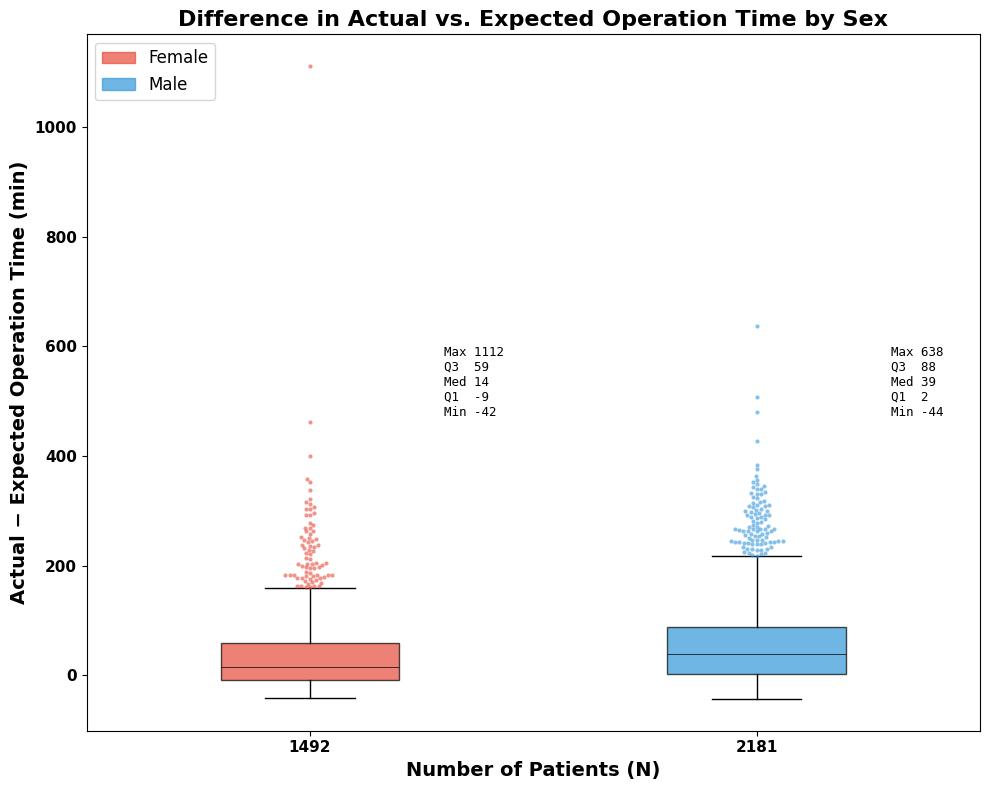

In [200]:
# We need a custom legend since we're splitting on a category.
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'female': '#E74C3C', 'male': '#3498DB'}

for i, sex in enumerate(['female', 'male']):
    subset = df_nonzero_los[df_nonzero_los['SEX'] == sex]['OPTIME_Diff']

    # Box plot without outliers
    bp = ax.boxplot(
        subset, positions=[i], widths=0.4, patch_artist=True, showfliers=False,
        medianprops=dict(
            color='black',
            linewidth=0.5
        ),
    )
    bp['boxes'][0].set_facecolor(colors[sex])
    bp['boxes'][0].set_alpha(0.7)

    # Get fence values
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    lower_fence = q1 - 1.5 * iqr

    # Beeswarm the outliers only
    outliers = subset[(subset > upper_fence) | (subset < lower_fence)]
    if len(outliers) > 0:
        sns.swarmplot(x=[i] * len(outliers), y=outliers, color=colors[sex],
                      size=3, ax=ax, alpha=0.6)

# Summary stats in a second loop after all plotting is done
for i, sex in enumerate(['female', 'male']):
    subset = df_nonzero_los[df_nonzero_los['SEX'] == sex]['OPTIME_Diff']
    med = subset.median()
    mn = subset.min()
    mx = subset.max()
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    y_mid = sum(ax.get_ylim()) / 2
    ax.text(i + 0.3, y_mid,
     f'Max {mx:.0f}\nQ3  {q3:.0f}\nMed {med:.0f}\nQ1  {q1:.0f}\nMin {mn:.0f}',
     fontsize=9, va='center', fontfamily='monospace'
    )

# X-axis: show N counts below labels
n_female = len(df_nonzero_los[df_nonzero_los['SEX'] == 'female'])
n_male = len(df_nonzero_los[df_nonzero_los['SEX'] == 'male'])
ax.set_xticks([0, 1])
ax.set_xticklabels([f'{n_female}', f'{n_male}'],
                   fontsize=11, fontweight='bold'
                   )
ax.set_xlabel('Number of Patients (N)', fontsize=14, fontweight='bold')

# Y-axis
ax.set_ylabel('Actual − Expected Operation Time (min)',
              fontsize=14, fontweight='bold'
              )
ax.tick_params(axis='y', labelsize=11)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Graph Title
ax.set_title('Difference in Actual vs. Expected Operation Time by Sex',
             fontsize=16, fontweight='bold'
             )

# Legend with color-coded categories
legend_patches = [mpatches.Patch(color=c, alpha=0.7, label=sex.capitalize())
                  for sex, c in colors.items()]
ax.legend(handles=legend_patches, fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

\newpage

## Categorized by Comorbidities Count (0,1,2,3+)

Made a few adjustments to this one:

- Legend moved to upper-right since the first category has an outlier pretty far up the y-axis.
- Lowered the summary stats padding a little so the right-most cateogry summary stats don't hug the box edge.
- Draw edges around the outlier plot points.

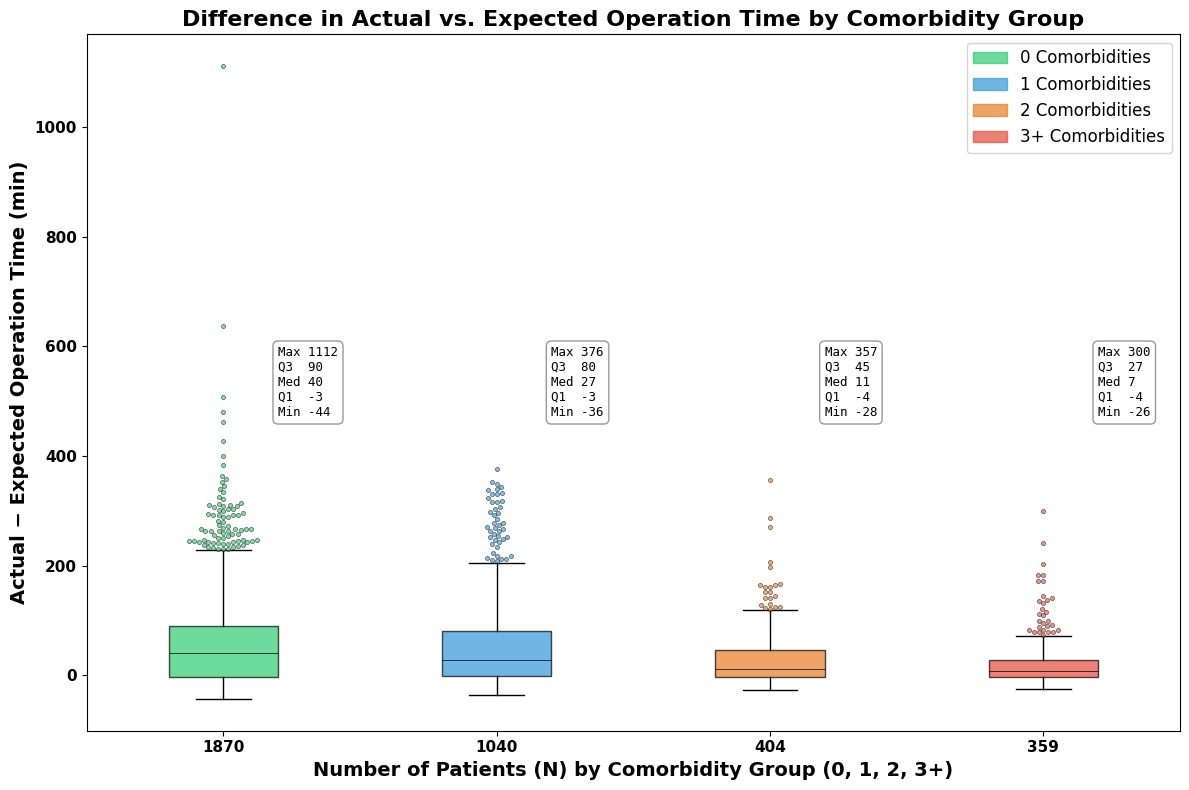

In [197]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 8))

categories = ['0', '1', '2', '3+']
colors = {'0': '#2ECC71', '1': '#3498DB', '2': '#E67E22', '3+': '#E74C3C'}

for i, cat in enumerate(categories):
    subset = df_nonzero_los[
        df_nonzero_los['COMORBIDITIES CAT'] == cat]['OPTIME_Diff'
    ]

    # Box plot without outliers
    bp = ax.boxplot(
        subset, positions=[i], widths=0.4,
        patch_artist=True, showfliers=False,
        medianprops=dict(
            color='black',
            linewidth=0.5
        ),
    )
    bp['boxes'][0].set_facecolor(colors[cat])
    bp['boxes'][0].set_alpha(0.7)

    # Get fence values
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    lower_fence = q1 - 1.5 * iqr

    # Beeswarm the outliers only
    outliers = subset[(subset > upper_fence) | (subset < lower_fence)]
    if len(outliers) > 0:
        sns.swarmplot(x=[i] * len(outliers), y=outliers, color=colors[cat],
                      size=3, ax=ax, alpha=0.6,
                      # Black lines around the outlier circles.
                      edgecolor='black',
                      # Thicker lines around the outlier circles.
                      linewidth=0.5,
                      )

# Summary stats after loop so y_mid is correct
for i, cat in enumerate(categories):
    subset = df_nonzero_los[
        df_nonzero_los['COMORBIDITIES CAT'] == cat]['OPTIME_Diff'
    ]
    med = subset.median()
    mn = subset.min()
    mx = subset.max()
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    y_mid = sum(ax.get_ylim()) / 2
    ax.text(i + 0.2, y_mid,
     f'Max {mx:.0f}\nQ3  {q3:.0f}\nMed {med:.0f}\nQ1  {q1:.0f}\nMin {mn:.0f}',
     fontsize=9, va='center', fontfamily='monospace',
     # Boxes around the summary stats.
     bbox=dict(
         boxstyle='round,pad=0.4', facecolor='white',
         edgecolor='gray', alpha=0.8
     )
    )

# X-axis: show N counts
counts = [
    len(
        df_nonzero_los[df_nonzero_los['COMORBIDITIES CAT'] == cat]
    ) for cat in categories
]
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(
    [str(c) for c in counts],
    fontsize=11, fontweight='bold'
)
ax.set_xlabel(
    'Number of Patients (N) by Comorbidity Group (0, 1, 2, 3+)',
    fontsize=14, fontweight='bold'
)

# Y-axis
ax.set_ylabel(
    'Actual − Expected Operation Time (min)',
    fontsize=14, fontweight='bold'
)
ax.tick_params(axis='y', labelsize=11)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Title
ax.set_title(
    'Difference in Actual vs. Expected Operation Time by Comorbidity Group',
             fontsize=16, fontweight='bold'
)

# Legend
legend_patches = [
    mpatches.Patch(color=colors[cat],
        alpha=0.7, label=f'{cat} Comorbidities'
    )
    for cat in categories
]
ax.legend(handles=legend_patches, fontsize=12, loc='upper right')

plt.tight_layout()
fig.savefig(
    '../Outputs/Images/comorbidity_fig.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
#plt.close(fig)

\newpage

# Exercise 2 - Summaries

## Results

In [195]:
#| echo: false
#| output: false
# Claude gave me the tip to save the summary dataframe as an output image.
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1,1.5) # Scale up row heights.
table.auto_set_column_width(
    col=list(
        range(len(results_df.columns))
    )
)
fig.savefig(
    '../Outputs/Images/results_table.png',
    dpi=300, bbox_inches='tight'
)
plt.close(fig)

![Results Table](../Outputs/Images/results_table.png)

![Difference in Actual vs. Expected Operation Time by Comorbidity Group](../Outputs/Images/comorbidity_fig.png){width=100%}

\newpage

## Journal Summary

A matched pairs t-test was conducted to evaluate whether actual operation time (OPTIME) significantly differed from expected operation time, where expected values were derived from the mean OPTIME per comorbidity group (0, 1, 2, 3+) in the full cleaned NSQIP dataset (n = 82,072). The analysis focused on patients with non-zero total hospital length of stay (n = 3,673).

Each patient's actual OPTIME was paired with an expected OPTIME based on their comorbidity burden, creating a dependent structure appropriate for a paired t-test. The large sample size ensures the Central Limit Theorem applies, making the test robust to the skewed distribution of OPTIME. Cohen's $d$ was used for effect-size comparisons.

Overall, the mean actual OPTIME (92.54 min) was significantly greater than the expected OPTIME (44.40 min), yielding a mean difference of 48.14 minutes (t = 39.08, p < .001). The standardized effect size (Cohen's $d$ = 0.645) indicates a **moderate** practical difference between actual and expected surgical times.  When stratified by comorbidity group, all four groups showed statistically significant differences (p < .001). (See Figure 1.)

The results indicate a statistically significant and moderate practical difference between actual and expected operation times among patients who required hospital stays. Notably, the size of the deviation decreases as the comorbidity burden increases: patients with zero comorbidities who were hospitalized showed the largest gap between actual and expected OPTIME (+57.43 min, d = 0.693), while those with 3+ comorbidities showed the smallest gap (+19.00 min, d = 0.462). This pattern suggests that comorbidity count alone may underestimate surgical complexity for healthier patients who otherwise require inpatient stays. This likely reflects more complex or unexpected procedures. The box plots confirm this trend, with the 0-comorbidity group exhibiting the widest spread and most extreme outliers in OPTIME difference scores. (See Figure 2.)


\newpage

## Stakeholder Summary

Our goal was to determine whether patients who stayed in the hospital experienced longer surgeries than expected based on the number of comorbidities (0,1,2,3+).

Understanding the gap between expected and actual surgery times helps hospitals plan resources, schedule operating rooms, and identify patients whose procedures may be more complex.

Patients with **fewer preoperative health conditions** (0 comorbidities) showed the **largest gap** between expected and actual surgery time (+57 minutes), while patients with **3 or more conditions** showed the **smallest gap** (+19 minutes). This suggests that when otherwise healthy patients require a hospital stay, the surgery itself tends to be more complex than we would expect given the comorbidity count.

The comorbidity count is a useful but incomplete predictor of surgical duration. Hospitalized patients - especially those with fewer pre-existing conditions - tend to undergo procedures that run significantly longer than expected. This finding supports the need for additional factors beyond comorbidity count information when estimating operating time and allocating surgical resources.
